# 1D convolution problem - 2 parameter prior

Recover 1D function from blurred, noisy data along with prior precision hyperparameter

Gaussian prior, gamma hyperpriors

Computes the distribution explicitly as in INLA

See "Efficient Marginalization-Based MCMC Methods for Hierarchical Bayesian Inverse Problems", Saibaba et al. 2019 and
"MCMC-Based Image Reconstruction with Uncertainty Quantification", Bardsley, 2012 for the example problem

In [1]:
import numpy as np
import scipy.stats as stats
import scipy.optimize as opt
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.linalg import solve_triangular

In [2]:
# Define the true signal (1D image)
def true_signal(x):
    return 50*np.exp(-((x-0.75)/0.1)**2) + 37*np.logical_and(x>0.1,x<0.25) + 13*np.logical_and(x>0.3,x<0.32) 

# Generate observed blurred data
def generate_blurred_data(true_signal, x, A, lam):
    noise_std = 1/np.sqrt(lam)
    blurred_signal = np.dot(A,true_signal(x))
    noise = np.random.normal(0, noise_std, len(x))
    return blurred_signal + noise

# Define a Gaussian blur kernel
def gaussian_kernel(x, gamma):
    return np.exp(-x**2 / (2 * gamma**2))/np.sqrt(np.pi*gamma**2)

# Explicitly compute log p(delta, gamma | data)
def logpi_gamma_delta(gamma, delta, lam, A, data):
    # compute prior precision L
    Lap = 2*np.diag(np.ones(N)) - np.diag(np.ones(N-1), k=1) - np.diag(np.ones(N-1), k=-1)
    Id = np.diag(np.ones(N))
    L = delta*Id + gamma*Lap
    L = np.dot(L,L)
    
    pr_mean = 10*np.ones(N)
    
    # compute posterior precision and mean
    Lpost = lam*np.dot(np.transpose(A),A) + L
    xpost = np.dot(L,pr_mean) + lam*np.dot(np.transpose(A),data)
    xpost = np.linalg.solve(Lpost, xpost)
    
    # compute negative log of determinant ratio
    (sdetL, logdetL) = np.linalg.slogdet(L)
    (sdetLpost, logdetLpost) = np.linalg.slogdet(Lpost)
    det_ratio = - 0.5*logdetLpost + 0.5*logdetL + N/2*np.log(lam) + \
        (alpha_del-1)*np.log(delta) + (alpha_gam-1)*np.log(gamma)
    
    # compute data, posterior mean, and hyperprior terms
    gd_prior = - beta_del*delta - beta_gam*gamma
    # uQu = -0.5*(lam*np.dot(data,data) - np.dot(xpost, np.dot(Lpost, xpost))) 
    uQu = 0.5*np.dot(xpost, np.dot(Lpost, xpost))
    muQmu = -0.5*np.dot(pr_mean,np.dot(L,pr_mean))
    
    return det_ratio + gd_prior + uQu + muQmu, det_ratio, gd_prior, uQu

In [3]:
# Parameters and generating noisy blurred data

np.random.seed(42)
# discretization dimension
N = 80
x = np.linspace(0, 1, N)
# width of convolution stencil -- in this case the full interval
kernel_size = N
# stdev of gaussian convolution kernel
kernel_gamma = 0.03
# noise precision
lam = 5.35
# hyperprior parameters
alpha_del = 1
alpha_gam = 1
beta_del = 1e-4
beta_gam = 1e-4
# number of Gibbs iterations
iters = 1000

# blurring matrix
A = np.zeros((N,N))
for i in range(N):
    for j in range(N):
        d = min(np.abs(i-j),N-np.abs(i-j))
        A[i,j] = gaussian_kernel(d/N, kernel_gamma)/N
# fix scaling (since h=1/N isn't small enough for the kernel to integrate to ~1 numerically)
A = A/np.sum(A[0,:]) 

# Generate data
observed_data = generate_blurred_data(true_signal, x, A, lam)

# # Initial guess for the hyperparameters
delta_initial = 0.4

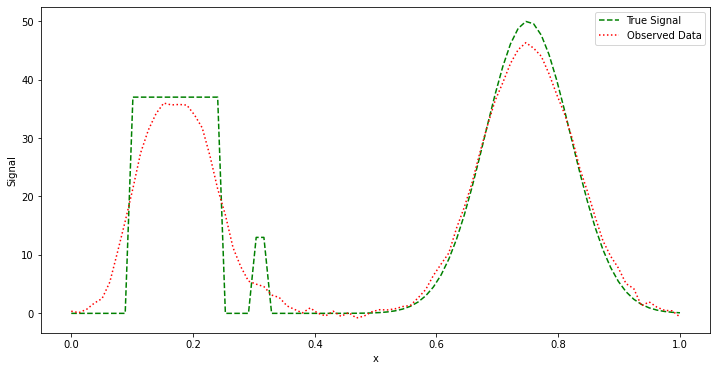

In [4]:
# Plot observations
plt.figure(figsize=(12, 6))
plt.plot(x, true_signal(x), label="True Signal", linestyle='dashed', color='green')
plt.plot(x, observed_data, label="Observed Data", linestyle='dotted', color='red')
plt.legend()
plt.xlabel("x")
plt.ylabel("Signal")
plt.show()

# INLA

In [5]:
del_range = np.linspace(0.0001, 0.035, 30)
gam_range = np.linspace(0.0001, 0.35, 30)

# del_range = np.linspace(0.0001, 100, 30)
# gam_range = np.linspace(0.0001, 2000, 30)

# compute - log pi(gamma, delta | data)
neglogpi = np.zeros((len(gam_range),len(del_range)))
det_ratios = np.zeros((len(gam_range),len(del_range)))
priors = np.zeros((len(gam_range),len(del_range)))
uQus = np.zeros((len(gam_range),len(del_range)))
for i in range(len(gam_range)):
    for j in range(len(del_range)):
        logpi_ij,det_ij,pri_ij,uQu_ij = logpi_gamma_delta(gam_range[i],del_range[j], lam, A, observed_data)
        neglogpi[i,j] = -logpi_ij
        det_ratios[i,j] = -det_ij
        priors[i,j] = -pri_ij
        uQus[i,j] = -uQu_ij

Text(0.5, 0, '$\\delta$')

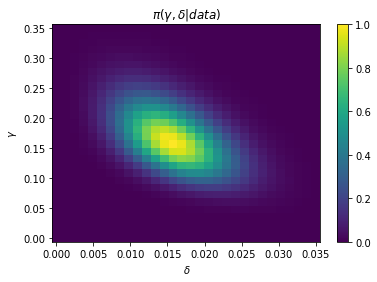

In [6]:
# plot pi(gamma, delta | data)
plt.pcolormesh(del_range,gam_range,np.exp(-neglogpi+np.min(neglogpi)))
plt.colorbar()
plt.title(r'$\pi(\gamma, \delta | data)$')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')

In [7]:
def neglogpi_helper(theta):
    logpi,det,pri,uQu = logpi_gamma_delta(theta[0],theta[1], lam, A, observed_data)
    return -logpi
theta0 = np.array([1, 1])
theta_opt = opt.minimize(neglogpi_helper,theta0,method='Nelder-Mead')

theta_MAP = theta_opt.x
print(theta_MAP)

[0.1599801  0.01554469]


<ipython-input-2-681d4fe7fdba>:35: RuntimeWarning: invalid value encountered in log
  (alpha_del-1)*np.log(delta) + (alpha_gam-1)*np.log(gamma)


Text(0.5, 0, 'x')

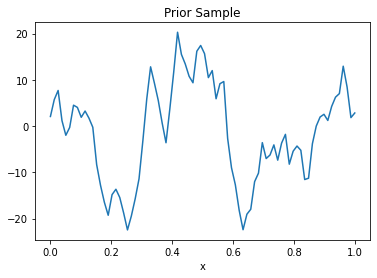

In [8]:
# sample from prior
# demonstrates that the smoothness and magnitude of samples with the recovered gamma and delta 
# resemble the original function
delta = theta_MAP[1]
gamma = theta_MAP[0]

Lap = 2*np.diag(np.ones(N)) - np.diag(np.ones(N-1), k=1) - np.diag(np.ones(N-1), k=-1)
Id = np.diag(np.ones(N))
L = delta*Id + gamma*Lap
# L = np.dot(L,L) # skip squaring it and taking the Cholesky decomposition since that's redundant
# K = np.linalg.cholesky(L)
w = np.linalg.solve(L,np.random.randn(N))

plt.plot(x,w)
plt.title('Prior Sample')
plt.xlabel('x')

In [9]:
# find inverse Hessian at MAP point
dgam = 1e-4
ddel = 1e-4
Hess_gg = (neglogpi_helper(theta_MAP-dgam*np.array([1,0]))
           -2*neglogpi_helper(theta_MAP)
           +neglogpi_helper(theta_MAP+dgam*np.array([1,0])))/dgam**2
Hess_gd = (neglogpi_helper(theta_MAP+dgam*np.array([1,0])+ddel*np.array([0,1]))
           +neglogpi_helper(theta_MAP)
           -neglogpi_helper(theta_MAP+dgam*np.array([1,0]))
           -neglogpi_helper(theta_MAP+ddel*np.array([0,1])))/dgam/ddel
Hess_dd = (neglogpi_helper(theta_MAP-ddel*np.array([0,1]))
           -2*neglogpi_helper(theta_MAP)
           +neglogpi_helper(theta_MAP+ddel*np.array([0,1])))/ddel**2
Hess_MAP = np.array([[Hess_gg,Hess_gd],[Hess_gd,Hess_dd]])
H_MAP_inv = np.linalg.inv(Hess_MAP)

# find principal directions
Hinv_lam,Hinv_V = np.linalg.eig(H_MAP_inv)
Hinv_L_sqrt = np.diag(np.sqrt(Hinv_lam))
def theta_of_z(z):
    return theta_MAP + np.dot(Hinv_V,np.dot(Hinv_L_sqrt,z))

In [10]:
# for each coordinate of z, find its values with significant probability
delta_z = 1
delta_pi = 2.5

z_highprob = [np.array([0.0]) for i in range(len(theta_MAP))]
for idx in range(len(theta_MAP)):
    z = np.array([0.0,0.0])
    z[idx] = delta_z
    while neglogpi_helper(theta_of_z(z)) - neglogpi_helper(theta_MAP) < delta_pi:
        z_highprob[idx] = np.append(z_highprob[idx],z[idx])
        z[idx] += delta_z
    z[idx] = -delta_z
    while neglogpi_helper(theta_of_z(z)) - neglogpi_helper(theta_MAP) < delta_pi:
        z_highprob[idx] = np.append(z_highprob[idx],z[idx])
        z[idx] -= delta_z

# check each pair to find quadrature points (not currently generalized to >2 parameters)
quad_points = []
for i in range(len(z_highprob[0])):
    for j in range(len(z_highprob[1])):
        theta_ij = theta_of_z(np.array([z_highprob[0][i],z_highprob[1][j]]))
        if neglogpi_helper(theta_ij) - neglogpi_helper(theta_MAP) < delta_pi:
            quad_points.append(theta_ij)
quad_points = np.array(quad_points)

Text(0.5, 0, '$\\delta$')

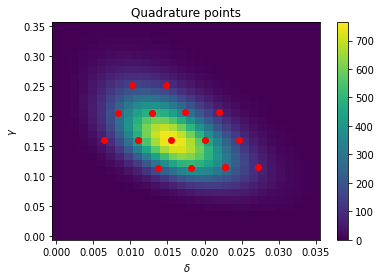

In [11]:
# approximate value of pi(gamma, delta | data) at MAP point, from Laplace approximation
scale = np.sqrt(np.linalg.det(Hess_MAP))/2/np.pi
neglogpiMAP = neglogpi_helper(theta_MAP)

fig = plt.figure()
# plot scaled pi(gamma, delta | data) with quadrature points
plt.pcolormesh(del_range,gam_range,np.exp(-neglogpi+neglogpiMAP)*scale)
plt.colorbar()
plt.scatter(quad_points[:,1],quad_points[:,0],color='red')
plt.title('Quadrature points')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')
# plt.axis('scaled')
# zoom = 20
# w, h = fig.get_size_inches()
# fig.set_size_inches(w * zoom, h * zoom)

In [12]:
# check that pi(gamma,delta | data) integrates to ~1 using quadrature
d_area = np.sqrt(np.prod(Hinv_lam))*delta_z**2*np.linalg.norm(np.cross(np.append(Hinv_V[0],0),np.append(Hinv_V[1],0)))
total = 0
for i in range(quad_points.shape[0]):
    total += np.exp(-neglogpi_helper(quad_points[i,:])+neglogpiMAP)*scale
total*d_area

0.902279337846798

In [13]:
# find pi(x^i|u_d) for each location i in locs at values x_eval of x
# in this case locations must be integer indices
def posterior_marginals(locs,x_eval,quad_points):
    output = np.zeros((len(locs),len(x_eval)))
    for idx in range(quad_points.shape[0]):
        gamma = quad_points[idx,0]
        delta = quad_points[idx,1]
        Lap = 2*np.diag(np.ones(N)) - np.diag(np.ones(N-1), k=1) - np.diag(np.ones(N-1), k=-1)
        Id = np.diag(np.ones(N))
        L = delta*Id + gamma*Lap
        L = np.dot(L,L)
        Lpost = lam*np.dot(np.transpose(A),A) + delta*L
        # mean and pointwise variance
        mm = np.linalg.solve(Lpost, lam*np.dot(np.transpose(A),observed_data))
        vv = np.diag(np.linalg.inv(Lpost))
        gauss_evals = np.zeros((len(locs),len(x_eval)))
        for ii in range(len(locs)):
            for jj in range(len(x_eval)):
                xx = x_eval[jj]
                gauss_evals[ii,jj] = np.exp(-(xx-mm[locs[ii]])**2/2/vv[locs[ii]])/np.sqrt(2*np.pi*vv[locs[ii]])
        # find pi(gamma, delta|u_d)
        neglogpi = neglogpi_helper(np.array([gamma,delta]))
        pi_gamma_delta = np.exp(-(neglogpi - neglogpiMAP))*scale
        
        output += d_area*pi_gamma_delta*gauss_evals
    return output

In [14]:
xx_range = np.linspace(-5.0,70.0,100)
locations = [16,40,60]
pi_xx_i_evals = posterior_marginals(locations,xx_range,quad_points)

In [15]:
pi_xx_i_evals_norms = trapezoid(pi_xx_i_evals,dx=xx_range[1]-xx_range[0],axis=1)
pi_xx_i_evals_normalized = (pi_xx_i_evals.T/pi_xx_i_evals_norms).T

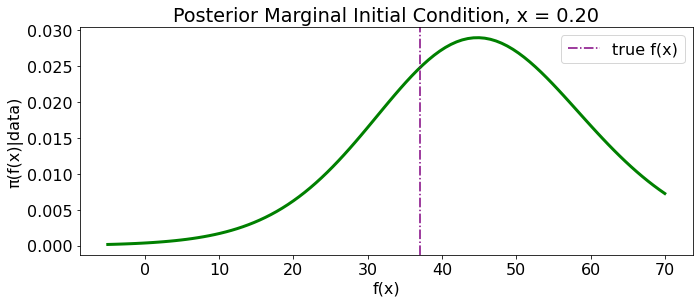

In [16]:
ii = 0

plt.figure(figsize=(10,4.5))
plt.rcParams.update({'font.size': 16})
plt.plot(xx_range,pi_xx_i_evals_normalized[ii,:],linewidth=3,color='green')
plt.axvline(x=true_signal(x[locations[ii]]), color='purple', linestyle="-.", label="true f(x)")
#plt.ticklabel_format(axis='both', style='sci', scilimits=(0,0))
plt.title(f'Posterior Marginal Initial Condition, x = {x[locations[ii]]:.2f}')
plt.ylabel("π(f(x)|data)")
plt.xlabel("f(x)")
plt.tight_layout()
plt.legend()
#plt.savefig("u_0_marginal.pdf")

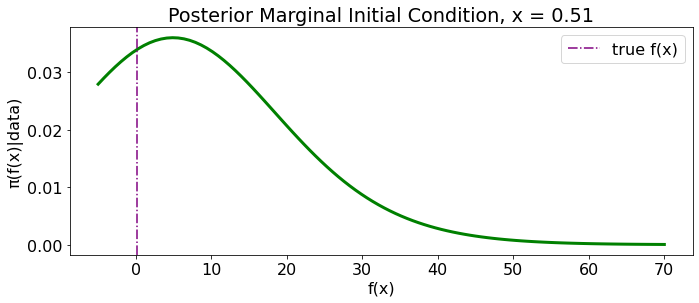

In [17]:
ii = 1

plt.figure(figsize=(10,4.5))
plt.rcParams.update({'font.size': 16})
plt.plot(xx_range,pi_xx_i_evals_normalized[ii,:],linewidth=3,color='green')
plt.axvline(x=true_signal(x[locations[ii]]), color='purple', linestyle="-.", label="true f(x)")
#plt.ticklabel_format(axis='both', style='sci', scilimits=(0,0))
plt.title(f'Posterior Marginal Initial Condition, x = {x[locations[ii]]:.2f}')
plt.ylabel("π(f(x)|data)")
plt.xlabel("f(x)")
plt.tight_layout()
plt.legend()
#plt.savefig("u_0_marginal.pdf")

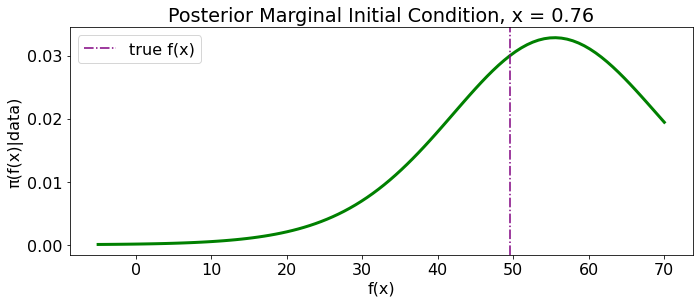

In [18]:
ii = 2

plt.figure(figsize=(10,4.5))
plt.rcParams.update({'font.size': 16})
plt.plot(xx_range,pi_xx_i_evals_normalized[ii,:],linewidth=3,color='green')
plt.axvline(x=true_signal(x[locations[ii]]), color='purple', linestyle="-.", label="true f(x)")
#plt.ticklabel_format(axis='both', style='sci', scilimits=(0,0))
plt.title(f'Posterior Marginal Initial Condition, x = {x[locations[ii]]:.2f}')
plt.ylabel("π(f(x)|data)")
plt.xlabel("f(x)")
plt.tight_layout()
plt.legend()
#plt.savefig("u_0_marginal.pdf")